# Lab Assignment: Skin Lesion Boundary Detection Using Canny Edge Detection
**Dataset:** HAM10000 (skin lesion dermoscopy images)  
**Pipeline:** Original → Grayscale → Gaussian filter → Canny edge detection → Lesion boundary → Area & perimeter

**Dataset loading:** the HAM10000 images are downloaded automatically with `kagglehub` (`kmader/skin-cancer-mnist-ham10000`).
The first run needs internet access and, if prompted, a Kaggle login; later runs reuse the cached copy.

## 0. Setup and helper functions

In [1]:
%pip install -q kagglehub opencv-python-headless pandas matplotlib

In [2]:
import os, glob, random
import kagglehub
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
IMAGE_IDS   = None            # optional: e.g. ["ISIC_0024306", "ISIC_0024307", ...] to pick your own 5 images
N_IMAGES    = 5
SEED        = 42
THRESHOLDS  = [(50, 100), (100, 200), (150, 250)]   # Canny (low, high) settings
GAUSS_KSIZE, GAUSS_SIGMA = (5, 5), 1.4
AVG_KSIZE, MED_KSIZE     = 5, 5
# ----------------------------------------

# ---- download / locate the HAM10000 dataset ----
DATASET_DIR = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Path to dataset files:", DATASET_DIR)

random.seed(SEED); np.random.seed(SEED)
plt.rcParams["figure.dpi"] = 100

# ---- locate images (searched recursively) ----
paths = {}
for ext in ("jpg", "jpeg", "png"):
    for p in glob.glob(os.path.join(DATASET_DIR, "**", f"*.{ext}"), recursive=True):
        paths[os.path.splitext(os.path.basename(p))[0]] = p
if not paths:
    raise FileNotFoundError(f"No images found under '{DATASET_DIR}'. The kagglehub download may have failed.")
print(f"Found {len(paths)} images.")

# ---- choose 5 images ----
if IMAGE_IDS is None:
    meta_files = glob.glob(os.path.join(DATASET_DIR, "**", "HAM10000_metadata.csv"), recursive=True)
    chosen = []
    if meta_files:
        meta = pd.read_csv(meta_files[0])
        meta = meta[meta["image_id"].isin(paths)]
        # one image from each of 5 different diagnosis classes (for variety)
        for dx in ["mel", "nv", "bkl", "bcc", "akiec", "df", "vasc"]:
            sub = meta[meta["dx"] == dx]
            if len(sub) and len(chosen) < N_IMAGES:
                chosen.append(sub.sample(1, random_state=SEED)["image_id"].iloc[0])
    if len(chosen) < N_IMAGES:
        chosen = random.sample(sorted(paths), N_IMAGES)
    IMAGE_IDS = chosen
names = [f"Image {i+1}" for i in range(len(IMAGE_IDS))]
print(dict(zip(names, IMAGE_IDS)))

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000
Found 10015 images.
{'Image 1': 'ISIC_0028847', 'Image 2': 'ISIC_0025438', 'Image 3': 'ISIC_0028750', 'Image 4': 'ISIC_0031597', 'Image 5': 'ISIC_0024646'}


In [3]:
# ======================= HELPER FUNCTIONS =======================
def ellipse(k):
    return cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))

def select_contour(contours, shape, min_frac=0.005, max_frac=0.9):
    """Pick the most likely lesion contour: large, but not the whole image, and close to the image centre."""
    h, w = shape[:2]
    img_area, diag = h * w, np.hypot(w, h)
    best, best_score = None, -1
    for c in contours:
        a = cv2.contourArea(c)
        if a < min_frac * img_area or a > max_frac * img_area:
            continue
        M = cv2.moments(c)
        if M["m00"] == 0:
            continue
        cx, cy = M["m10"] / M["m00"], M["m01"] / M["m00"]
        d = np.hypot(cx - w / 2, cy - h / 2) / diag          # normalised distance from centre
        score = a * np.exp(-(d / 0.25) ** 2)                 # prefer big AND central
        if score > best_score:
            best, best_score = c, score
    return best

def edges_to_boundary(edges):
    """Edge map -> (filled lesion mask, lesion contour) using morphological closing + contour detection."""
    c = None
    for k in (9, 15, 25, 35):                                 # increase closing size until a closed region appears
        closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, ellipse(k))
        contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        c = select_contour(contours, edges.shape)
        if c is not None:
            break
    mask = np.zeros_like(edges)
    if c is None:
        return mask, None
    cv2.drawContours(mask, [c], -1, 255, thickness=-1)        # fill the region inside the boundary
    # remove thin protrusions (e.g. hairs attached to the outline) with a morphological opening, then re-trace the boundary
    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, ellipse(21))
    cs, _ = cv2.findContours(opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    c2 = select_contour(cs, edges.shape)
    if c2 is not None:
        mask = np.zeros_like(edges)
        cv2.drawContours(mask, [c2], -1, 255, thickness=-1)
        c = c2
    return mask, c

def otsu_reference(gray):
    """Pseudo reference lesion mask (Otsu thresholding). NOT ground truth - only used as a comparison proxy."""
    blur = cv2.GaussianBlur(gray, (7, 7), 0)
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)   # lesion is darker than skin
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, ellipse(7))
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, ellipse(15))
    contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    c = select_contour(contours, th.shape)
    mask = np.zeros_like(th)
    if c is not None:
        cv2.drawContours(mask, [c], -1, 255, thickness=-1)
    return mask

def iou(a, b):
    a, b = a > 0, b > 0
    union = np.logical_or(a, b).sum()
    return float(np.logical_and(a, b).sum() / union) if union else 0.0

def edge_precision(edges, ref_mask, tol=6):
    """Fraction of edge pixels lying within `tol` px of the reference lesion boundary (higher = less clutter)."""
    ref_boundary = cv2.morphologyEx(ref_mask, cv2.MORPH_GRADIENT, np.ones((3, 3), np.uint8))
    if ref_boundary.sum() == 0:
        return 0.0
    dist = cv2.distanceTransform(255 - ref_boundary, cv2.DIST_L2, 3)
    ys, xs = np.nonzero(edges)
    return float((dist[ys, xs] <= tol).mean()) if len(ys) else 0.0

def noise_sigma(gray):
    """Immerkaer's fast noise-level estimate (lower = less noise)."""
    H, W = gray.shape
    K = np.array([[1, -2, 1], [-2, 4, -2], [1, -2, 1]], dtype=np.float64)
    conv = cv2.filter2D(gray.astype(np.float64), -1, K)[2:-2, 2:-2]
    return float(np.sqrt(np.pi / 2) * np.abs(conv).sum() / (6 * (W - 2) * (H - 2)))

def sobel_edges(gray):
    """Sobel gradient magnitude, binarised with Otsu so it can be used like a Canny edge map."""
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mag = cv2.normalize(np.hypot(gx, gy), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, e = cv2.threshold(mag, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return e

def show_row(images, titles, cmaps=None, figsize=None, suptitle=None):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize or (4 * n, 4))
    axes = np.atleast_1d(axes)
    for i, ax in enumerate(axes):
        ax.imshow(images[i], cmap=(cmaps[i] if cmaps else None)); ax.set_title(titles[i], fontsize=10); ax.axis("off")
    if suptitle: fig.suptitle(suptitle, fontsize=12)
    plt.tight_layout(); plt.show()

## Task 1 — Load the Image
Five images are selected from HAM10000 and displayed in their original (colour) form.

Image 1: ISIC_0028847  shape=(450, 600, 3)
Image 2: ISIC_0025438  shape=(450, 600, 3)
Image 3: ISIC_0028750  shape=(450, 600, 3)
Image 4: ISIC_0031597  shape=(450, 600, 3)
Image 5: ISIC_0024646  shape=(450, 600, 3)


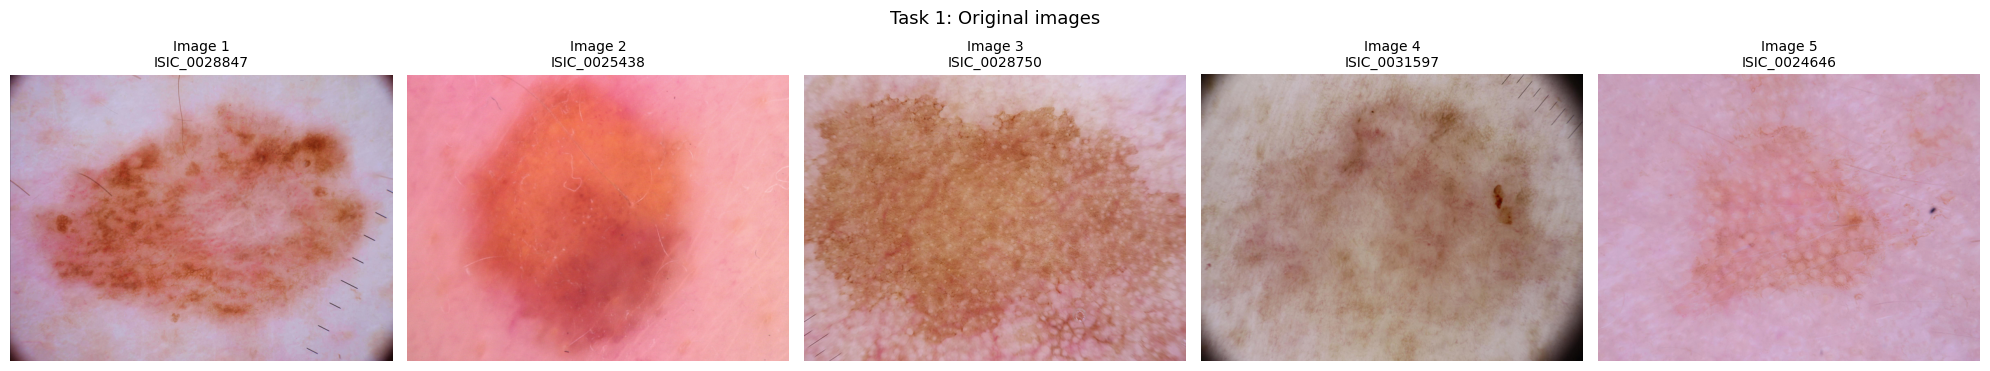

In [4]:
originals = {}
for name, iid in zip(names, IMAGE_IDS):
    bgr = cv2.imread(paths[iid])
    originals[name] = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)     # OpenCV loads BGR; matplotlib expects RGB
    print(f"{name}: {iid}  shape={originals[name].shape}")

fig, axes = plt.subplots(1, len(names), figsize=(4 * len(names), 4))
for ax, name, iid in zip(axes, names, IMAGE_IDS):
    ax.imshow(originals[name]); ax.set_title(f"{name}\n{iid}", fontsize=10); ax.axis("off")
plt.suptitle("Task 1: Original images", fontsize=13); plt.tight_layout(); plt.show()

## Task 2 — Preprocess the Image
1. Convert to grayscale (Canny works on intensity gradients, so colour is not needed).
2. Apply a **Gaussian filter** (5×5, σ = 1.4) to suppress noise and fine hair/texture detail.

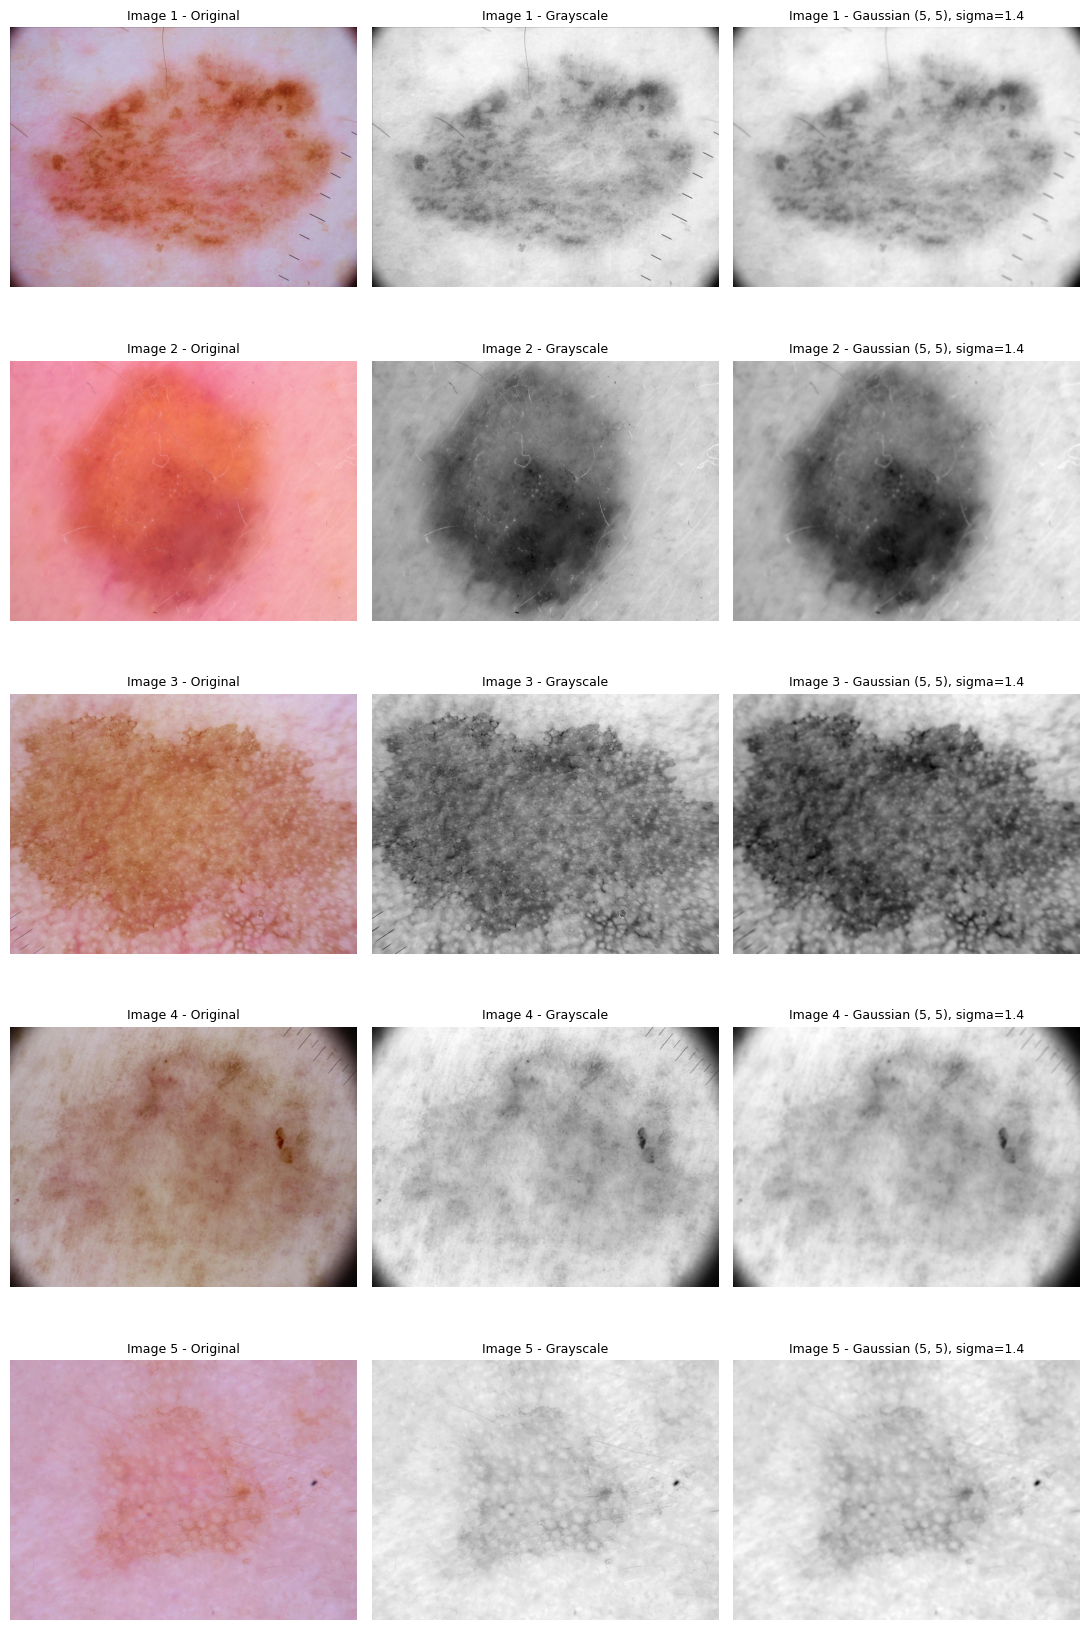

In [5]:
grays, gausses = {}, {}
for name in names:
    grays[name]   = cv2.cvtColor(originals[name], cv2.COLOR_RGB2GRAY)
    gausses[name] = cv2.GaussianBlur(grays[name], GAUSS_KSIZE, GAUSS_SIGMA)

fig, axes = plt.subplots(len(names), 3, figsize=(11, 3.4 * len(names)))
for r, name in enumerate(names):
    for ax, img, t, cm in zip(axes[r], [originals[name], grays[name], gausses[name]],
                              ["Original", "Grayscale", f"Gaussian {GAUSS_KSIZE}, sigma={GAUSS_SIGMA}"], [None, "gray", "gray"]):
        ax.imshow(img, cmap=cm); ax.set_title(f"{name} - {t}", fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

## Task 3 — Apply Canny Edge Detection
Canny is applied to the Gaussian-filtered image with three (low, high) threshold settings: **50–100**, **100–200**, **150–250**.

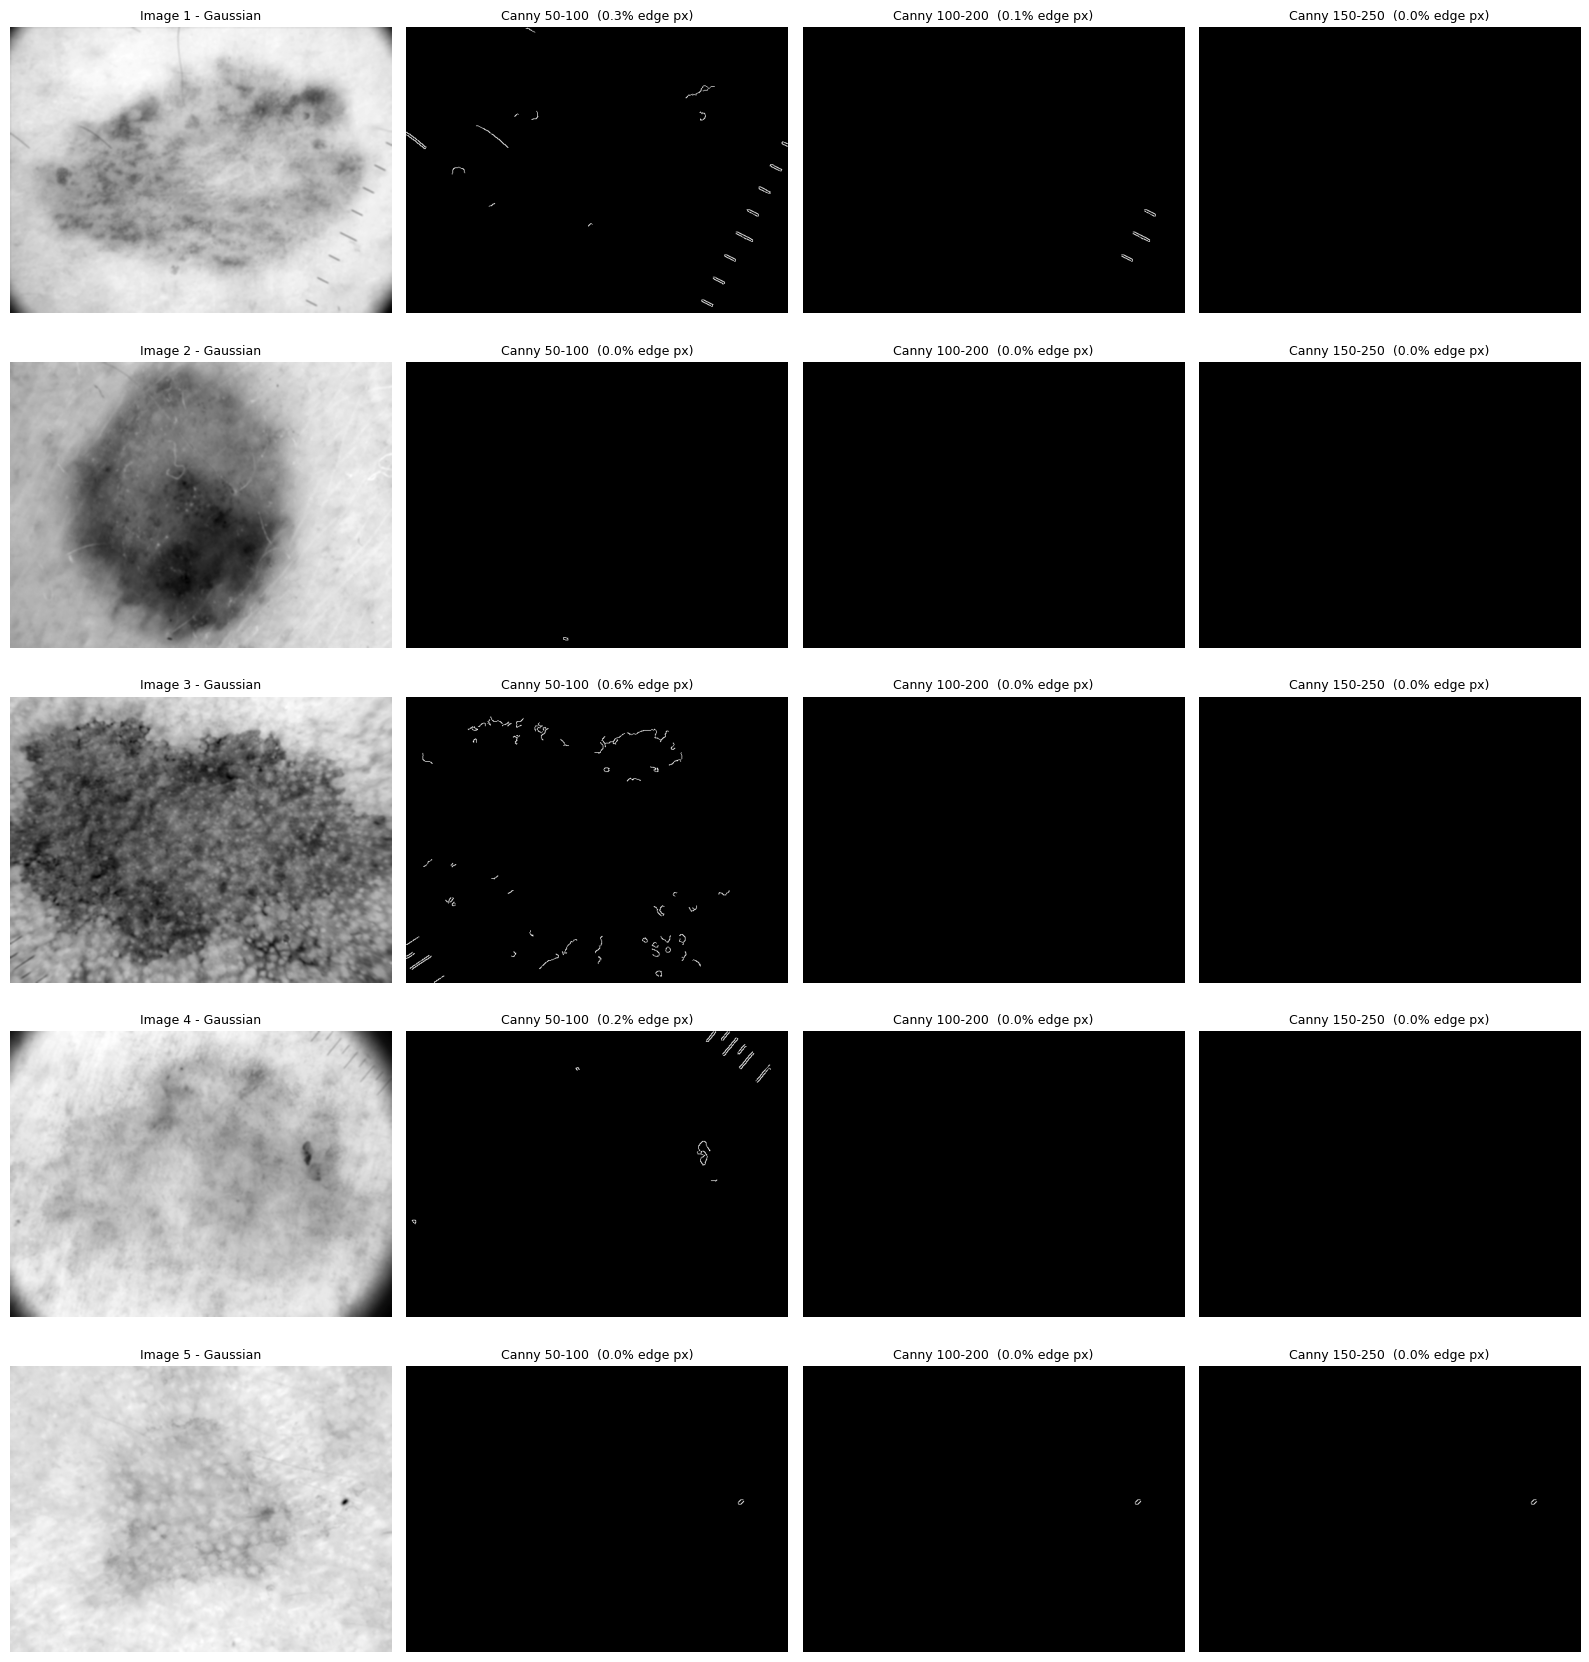

In [6]:
canny_maps = {}   # canny_maps[name][(lo, hi)] -> edge map
for name in names:
    canny_maps[name] = {t: cv2.Canny(gausses[name], t[0], t[1]) for t in THRESHOLDS}

fig, axes = plt.subplots(len(names), 4, figsize=(16, 3.4 * len(names)))
for r, name in enumerate(names):
    axes[r, 0].imshow(gausses[name], cmap="gray"); axes[r, 0].set_title(f"{name} - Gaussian", fontsize=9)
    for c, t in enumerate(THRESHOLDS, start=1):
        axes[r, c].imshow(canny_maps[name][t], cmap="gray")
        axes[r, c].set_title(f"Canny {t[0]}-{t[1]}  ({(canny_maps[name][t] > 0).mean()*100:.1f}% edge px)", fontsize=9)
    for ax in axes[r]: ax.axis("off")
plt.tight_layout(); plt.show()

## Task 4 — Select the Best Result
Looking at the edge maps is the first step, but to make the choice objective each threshold is also scored with two measures:

- **Edge precision** – share of edge pixels that lie close to the lesion outline (higher = less clutter from hair/skin texture).
- **IoU** – overlap between the lesion mask obtained from those edges (Task 5 method) and an **Otsu-threshold reference mask**.

> HAM10000's main download has no lesion masks, so the Otsu mask is only a *proxy* reference, not ground truth.
> The final score is `0.5 * precision + 0.5 * IoU`. Always confirm the choice visually as well.

In [7]:
ref_masks = {name: otsu_reference(gausses[name]) for name in names}

rows = []
for name in names:
    for t in THRESHOLDS:
        e = canny_maps[name][t]
        m, _ = edges_to_boundary(e)
        p, j = edge_precision(e, ref_masks[name]), iou(m, ref_masks[name])
        rows.append({"Image": name, "Threshold": f"{t[0]}-{t[1]}", "Edge density %": round((e > 0).mean() * 100, 2),
                     "Edge precision": round(p, 3), "IoU vs Otsu": round(j, 3), "Score": round(0.5 * p + 0.5 * j, 3)})
score_df = pd.DataFrame(rows)
display(score_df)

best_thr = {}
for name in names:
    sub = score_df[score_df["Image"] == name]
    lo, hi = sub.loc[sub["Score"].idxmax(), "Threshold"].split("-")
    best_thr[name] = (int(lo), int(hi))

mean_scores = score_df.groupby("Threshold")["Score"].mean().sort_values(ascending=False)
print("Mean score per threshold across all images:\n", mean_scores.round(3).to_string())
lo, hi = mean_scores.index[0].split("-")
GLOBAL_BEST = (int(lo), int(hi))
print("\nBest threshold per image:", best_thr)
print("Best overall threshold   :", GLOBAL_BEST)

# Optional manual override after you have looked at the edge maps, e.g.:
# best_thr["Image 1"] = (100, 200)

,Image,Threshold,Edge density %,Edge precision,IoU vs Otsu,Score
0,Image 1,50-100,0.31,0.052,0.000,0.026
1,Image 1,100-200,0.07,0.000,0.000,0.000
2,Image 1,150-250,0.00,0.000,0.000,0.000
3,Image 2,50-100,0.01,0.050,0.000,0.025
4,Image 2,100-200,0.00,0.000,0.000,0.000
5,Image 2,150-250,0.00,0.000,0.000,0.000
6,Image 3,50-100,0.60,0.362,0.008,0.185
7,Image 3,100-200,0.00,0.000,0.000,0.000
8,Image 3,150-250,0.00,0.000,0.000,0.000
9,Image 4,50-100,0.22,0.007,0.000,0.003


Mean score per threshold across all images:
 Threshold
50-100     0.048
100-200    0.000
150-250    0.000

Best threshold per image: {'Image 1': (50, 100), 'Image 2': (50, 100), 'Image 3': (50, 100), 'Image 4': (50, 100), 'Image 5': (50, 100)}
Best overall threshold   : (50, 100)


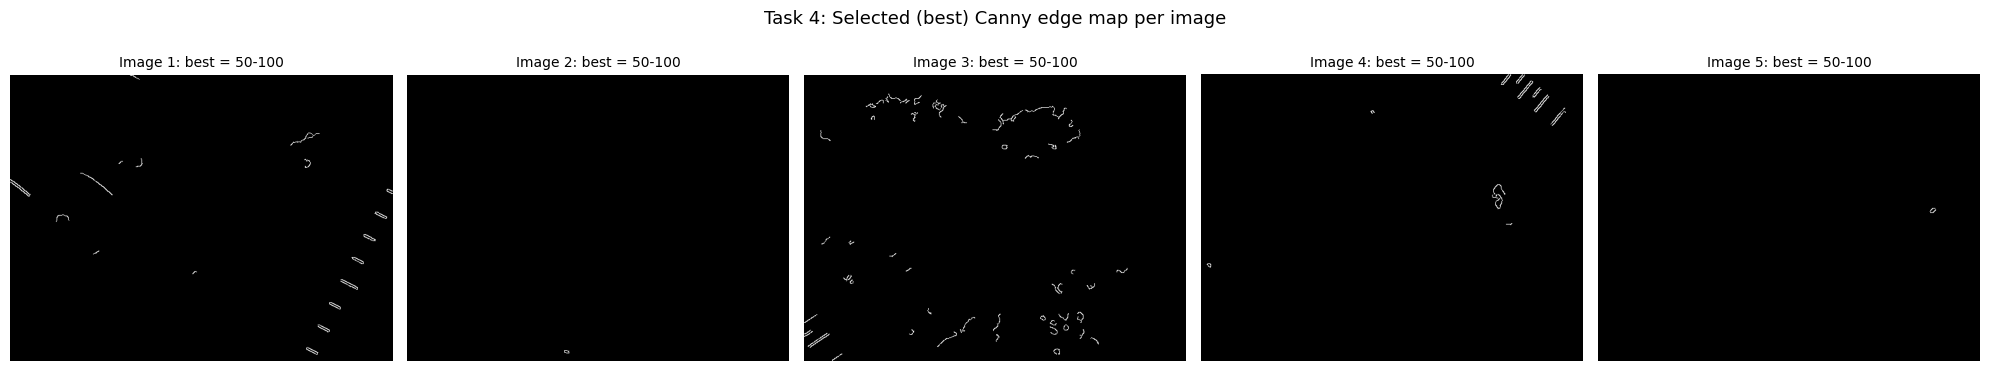

In [8]:
fig, axes = plt.subplots(1, len(names), figsize=(4 * len(names), 4))
for ax, name in zip(axes, names):
    ax.imshow(canny_maps[name][best_thr[name]], cmap="gray")
    ax.set_title(f"{name}: best = {best_thr[name][0]}-{best_thr[name][1]}", fontsize=10); ax.axis("off")
plt.suptitle("Task 4: Selected (best) Canny edge map per image", fontsize=13); plt.tight_layout(); plt.show()

### Why this threshold? (explanation for Task 4)
*Fill in / adjust after you have looked at your own outputs above.*

- **Low thresholds (50–100)** keep weak gradients, so hair, skin texture and the dermoscope vignette appear as many extra edges. The lesion outline is present but buried in clutter.
- **High thresholds (150–250)** keep only very strong gradients. Clutter disappears, but lesions with soft/blurry borders get broken or missing outline segments, so the boundary is no longer closed.
- **Medium thresholds (100–200)** usually give the best balance: the lesion outline is continuous while most noise edges are rejected by hysteresis. The score table above shows which setting actually won for each image and overall; the selected threshold is the one with the highest score *and* the clearest visible outline.

## Task 5 — Detect the Lesion Boundary
Method (edges → boundary):
1. Take the best Canny edge map.
2. **Morphological closing** (elliptical kernel, grown 9 → 35 px if needed) to bridge small gaps in the outline.
3. **Contour detection** (`cv2.findContours`, external contours only).
4. Keep the contour that is **large and close to the image centre** (rejects hair, border vignette and corners).
5. Fill it to obtain the lesion mask, apply a **morphological opening** to cut off thin hair-like protrusions, and draw the boundary on the original image.

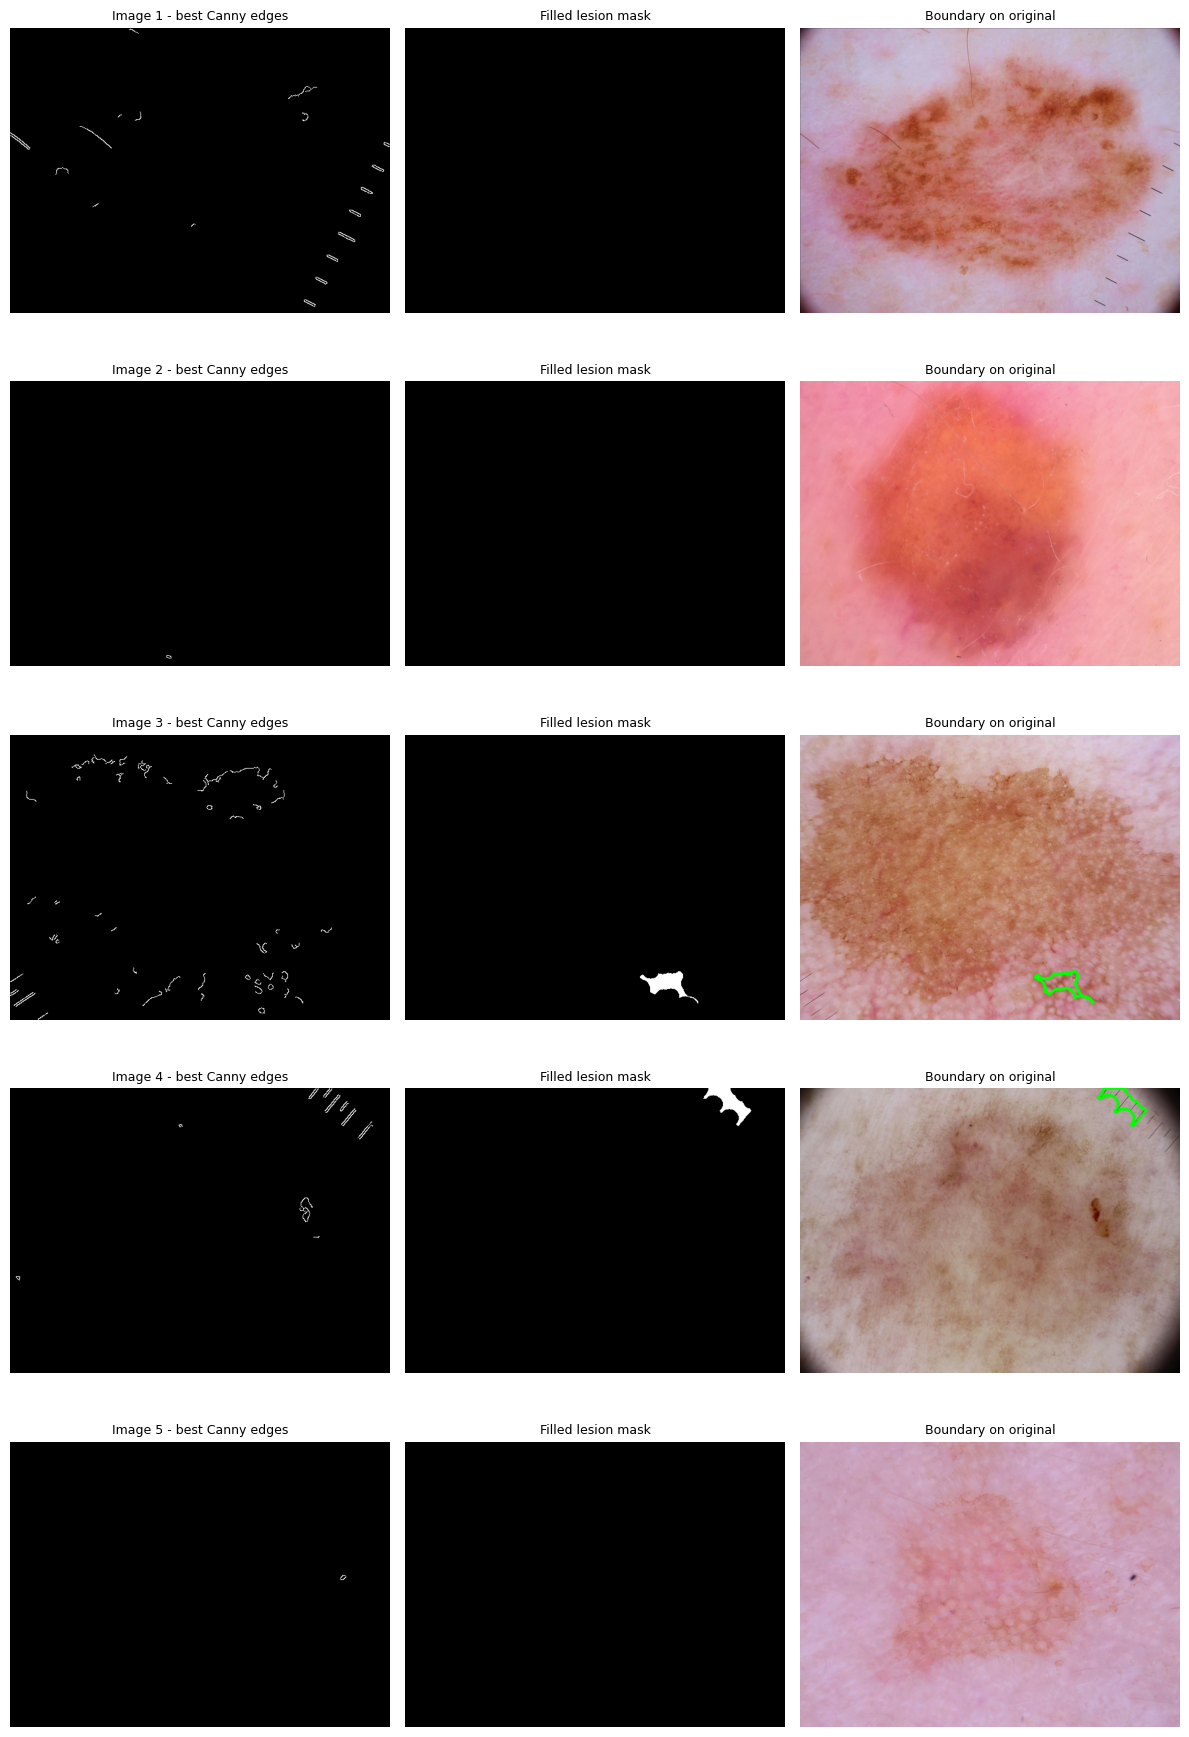

In [9]:
masks, contours_out, overlays = {}, {}, {}
for name in names:
    mask, cnt = edges_to_boundary(canny_maps[name][best_thr[name]])
    masks[name], contours_out[name] = mask, cnt
    ov = originals[name].copy()
    if cnt is not None:
        cv2.drawContours(ov, [cnt], -1, (0, 255, 0), 3)
    else:
        print(f"WARNING: no lesion contour found for {name}; try another threshold in best_thr.")
    overlays[name] = ov

fig, axes = plt.subplots(len(names), 3, figsize=(12, 3.6 * len(names)))
for r, name in enumerate(names):
    axes[r, 0].imshow(canny_maps[name][best_thr[name]], cmap="gray"); axes[r, 0].set_title(f"{name} - best Canny edges", fontsize=9)
    axes[r, 1].imshow(masks[name], cmap="gray");                      axes[r, 1].set_title("Filled lesion mask", fontsize=9)
    axes[r, 2].imshow(overlays[name]);                                axes[r, 2].set_title("Boundary on original", fontsize=9)
    for ax in axes[r]: ax.axis("off")
plt.tight_layout(); plt.show()

## Task 6 — Calculate Lesion Area and Perimeter
- **Area** = number of pixels inside the detected boundary (non-zero pixels of the filled mask).
- **Perimeter** = length of the boundary curve in pixels (`cv2.arcLength`).

In [10]:
results = []
for name in names:
    mask, cnt = masks[name], contours_out[name]
    area = int((mask > 0).sum())
    perim = round(float(cv2.arcLength(cnt, True)), 1) if cnt is not None else 0.0
    results.append({"Image": name, "Best Filter": "Gaussian",
                    "Edge Method": f"Canny ({best_thr[name][0]}-{best_thr[name][1]})",
                    "Area (pixels)": area, "Perimeter (pixels)": perim})
results_df = pd.DataFrame(results)
display(results_df)
results_df.to_csv("lesion_results.csv", index=False)

,Image,Best Filter,Edge Method,Area (pixels),Perimeter (pixels)
0,Image 1,Gaussian,Canny (50-100),0,0.0
1,Image 2,Gaussian,Canny (50-100),0,0.0
2,Image 3,Gaussian,Canny (50-100),1571,277.7
3,Image 4,Gaussian,Canny (50-100),1569,253.8
4,Image 5,Gaussian,Canny (50-100),0,0.0


## Required Visualization
**Original → Grayscale → Gaussian Filter → Canny → Lesion Boundary** for every image, with the area and perimeter.

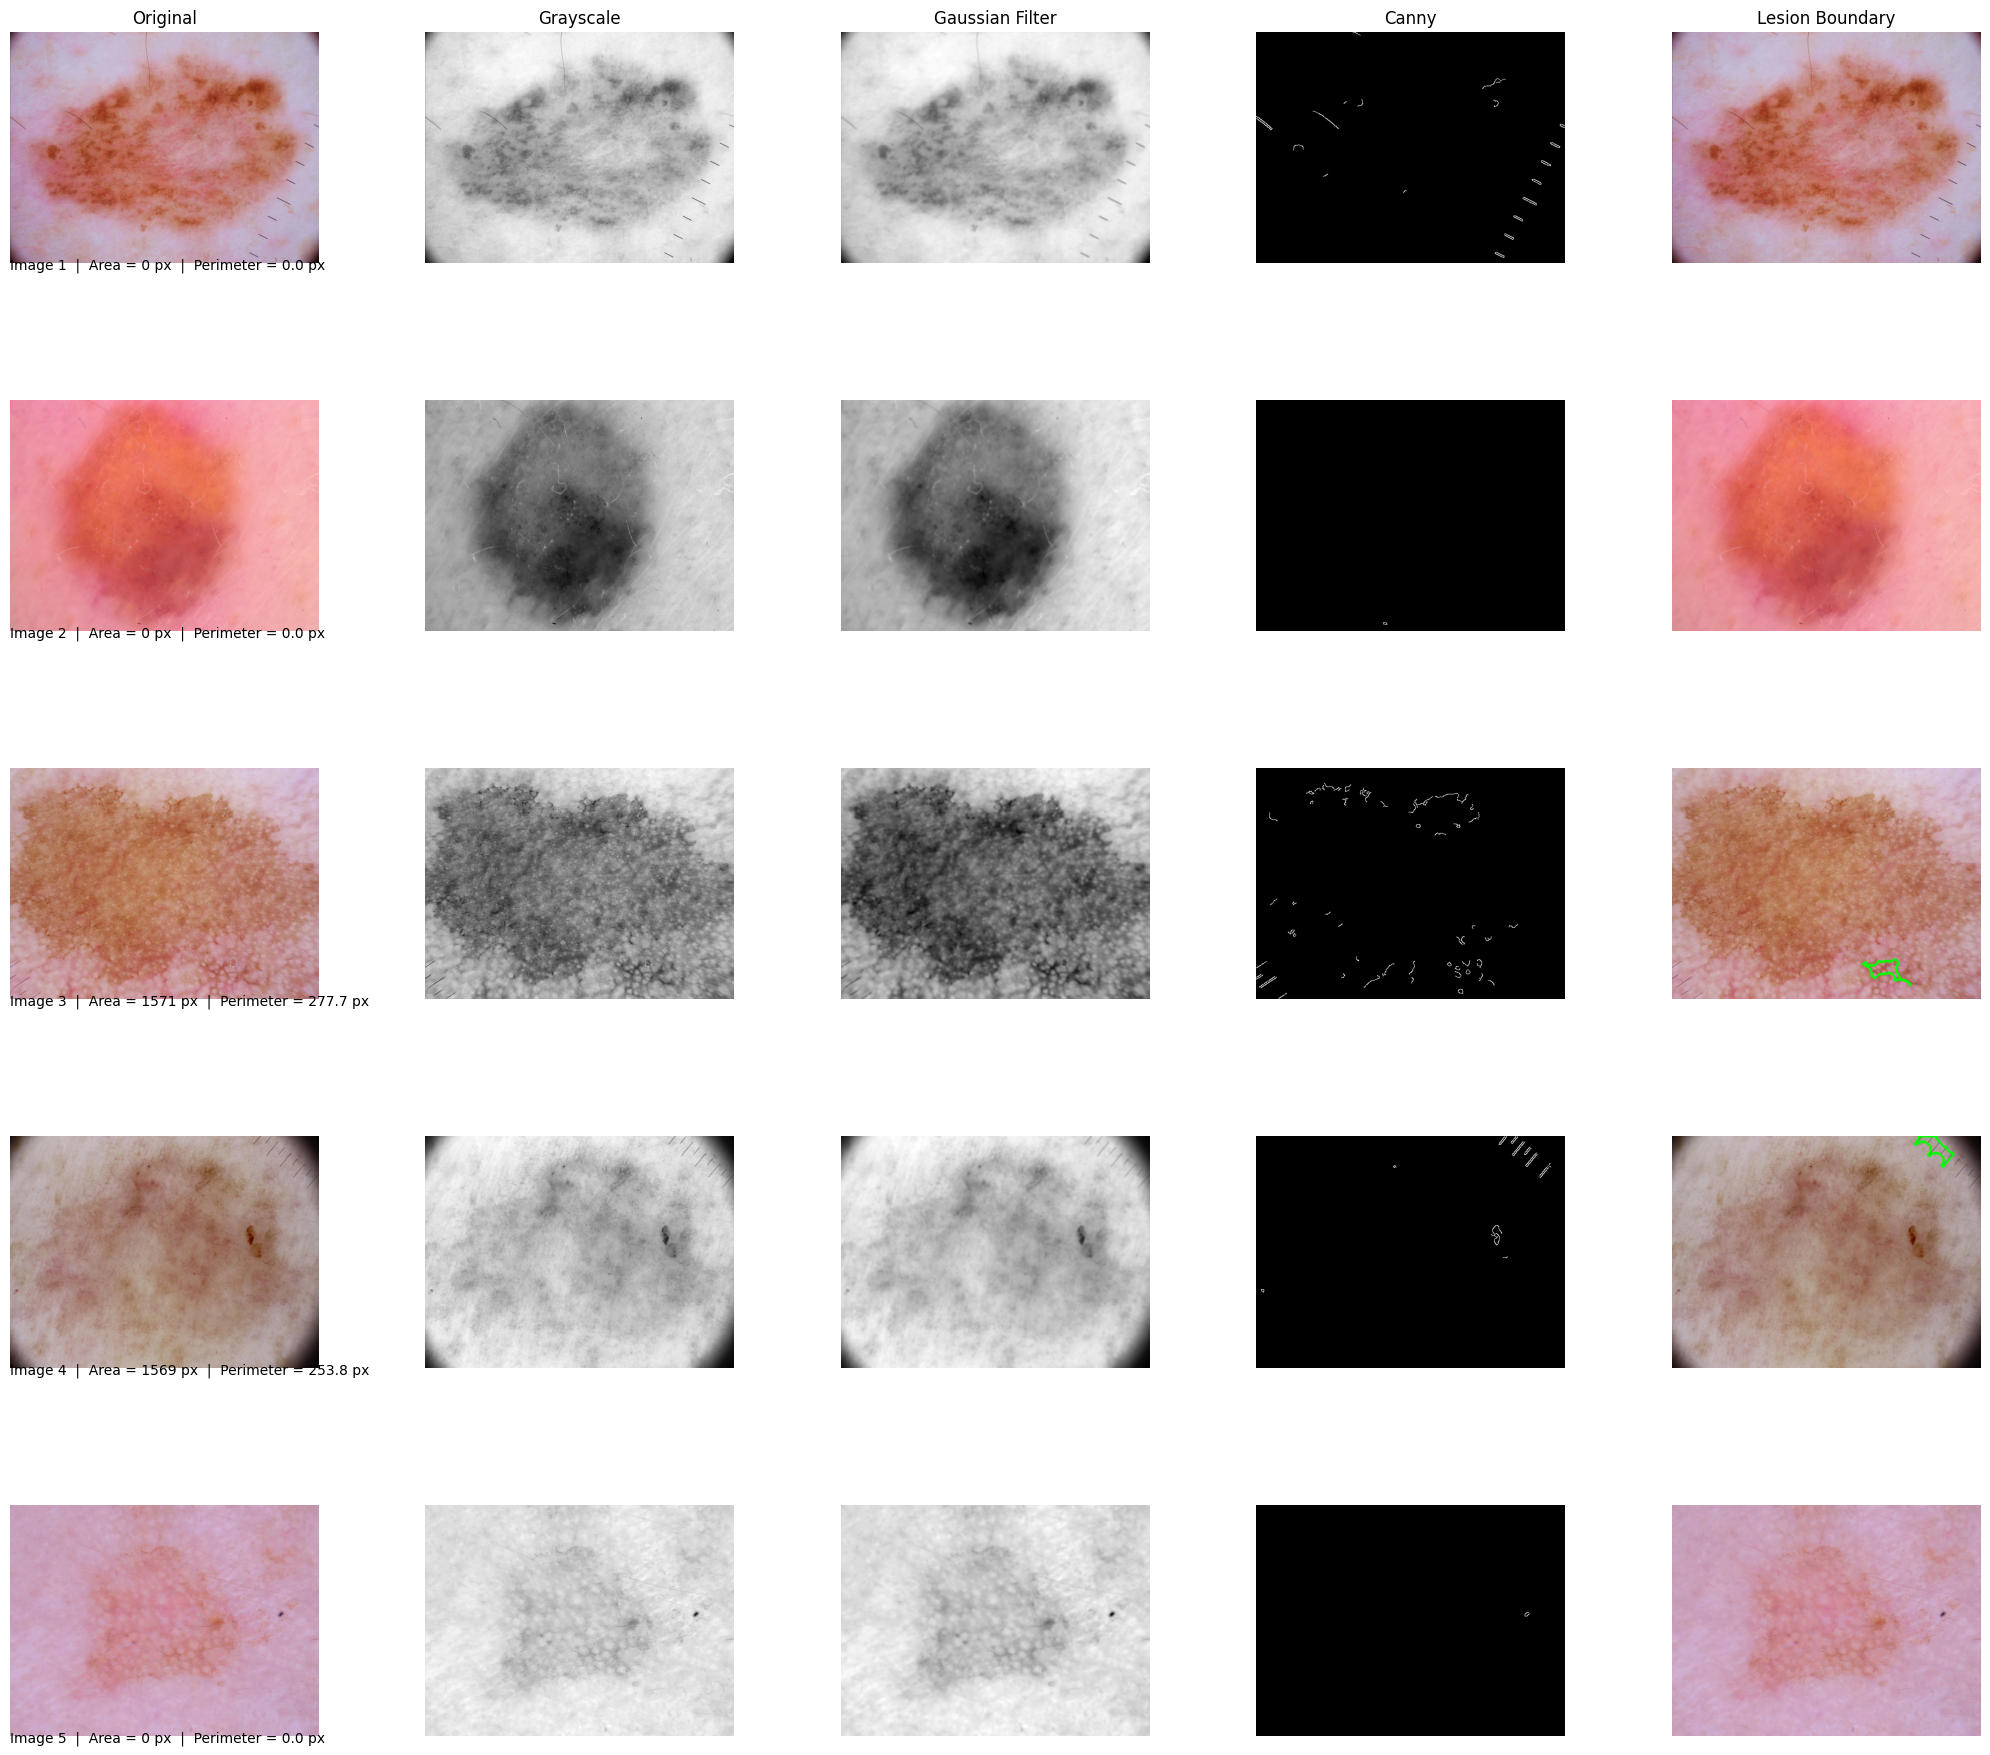

In [11]:
titles = ["Original", "Grayscale", "Gaussian Filter", "Canny", "Lesion Boundary"]
fig, axes = plt.subplots(len(names), 5, figsize=(20, 3.8 * len(names)))
for r, name in enumerate(names):
    imgs = [originals[name], grays[name], gausses[name], canny_maps[name][best_thr[name]], overlays[name]]
    cms  = [None, "gray", "gray", "gray", None]
    for c in range(5):
        axes[r, c].imshow(imgs[c], cmap=cms[c]); axes[r, c].axis("off")
        axes[r, c].set_title(titles[c] if r == 0 else "", fontsize=12)
    row = results_df.iloc[r]
    axes[r, 0].text(0, -0.04, f"{name}  |  Area = {row['Area (pixels)']} px  |  Perimeter = {row['Perimeter (pixels)']} px",
                    transform=axes[r, 0].transAxes, fontsize=10, va="bottom")
plt.tight_layout(); plt.savefig("pipeline_visualization.png", dpi=120, bbox_inches="tight"); plt.show()

In [12]:
print("Lesion Results Table")
display(results_df.style.hide(axis="index"))

Lesion Results Table


Image,Best Filter,Edge Method,Area (pixels),Perimeter (pixels)
Image 1,Gaussian,Canny (50-100),0,0.000000
Image 2,Gaussian,Canny (50-100),0,0.000000
Image 3,Gaussian,Canny (50-100),1571,277.700000
Image 4,Gaussian,Canny (50-100),1569,253.800000
Image 5,Gaussian,Canny (50-100),0,0.000000


## Final Comparison — Filter × Edge Operator
Four pre-filters (**Original, Average 5×5, Gaussian 5×5, Median 5×5**) are each combined with two edge operators (**Sobel, Canny**), giving 8 methods, evaluated on all 5 images.
Canny uses the best overall threshold found in Task 4. Metrics (averaged over the images):

| Column | Measure | Better |
|---|---|---|
| Noise Handling | Immerkaer noise estimate σ of the filtered image | lower |
| Edge Quality | Edge precision (edge pixels near the lesion outline) | higher |
| Boundary Detection | IoU of the detected lesion mask vs Otsu reference | higher |
| Overall Performance | Mean rank of the three measures | lower rank = better |

In [13]:
filters = {
    "Original": lambda g: g,
    "Average":  lambda g: cv2.blur(g, (AVG_KSIZE, AVG_KSIZE)),
    "Gaussian": lambda g: cv2.GaussianBlur(g, GAUSS_KSIZE, GAUSS_SIGMA),
    "Median":   lambda g: cv2.medianBlur(g, MED_KSIZE),
}
operators = {
    "Sobel": sobel_edges,
    "Canny": lambda g: cv2.Canny(g, GLOBAL_BEST[0], GLOBAL_BEST[1]),
}

records = []
comparison_edges = {}   # kept for the visual comparison below
for name in names:
    for fname, f in filters.items():
        filt = f(grays[name])
        sig = noise_sigma(filt)
        for oname, op in operators.items():
            e = op(filt)
            m, _ = edges_to_boundary(e)
            comparison_edges[(name, fname, oname)] = e
            records.append({"Method": f"{fname} + {oname}", "Image": name, "sigma": sig,
                            "precision": edge_precision(e, ref_masks[name]), "iou": iou(m, ref_masks[name])})
rec = pd.DataFrame(records)
avg = rec.groupby("Method", sort=False)[["sigma", "precision", "iou"]].mean()

order = ["Original + Sobel", "Original + Canny", "Average + Sobel", "Average + Canny",
         "Gaussian + Sobel", "Gaussian + Canny", "Median + Sobel", "Median + Canny"]
avg = avg.loc[order]
avg["rank_noise"] = avg["sigma"].rank(ascending=True)
avg["rank_edge"]  = avg["precision"].rank(ascending=False)
avg["rank_bound"] = avg["iou"].rank(ascending=False)
avg["mean_rank"]  = avg[["rank_noise", "rank_edge", "rank_bound"]].mean(axis=1)
avg["rank_overall"] = avg["mean_rank"].rank(method="min")

def label(rank):   # tertile-style label from the rank among 8 methods
    return "Good" if rank <= 3 else ("Moderate" if rank <= 6 else "Poor")

final_table = pd.DataFrame({
    "Method": avg.index,
    "Noise Handling":      [f"{label(r)} (sigma={s:.2f})"   for r, s in zip(avg["rank_noise"], avg["sigma"])],
    "Edge Quality":        [f"{label(r)} (prec={p:.2f})"    for r, p in zip(avg["rank_edge"],  avg["precision"])],
    "Boundary Detection":  [f"{label(r)} (IoU={j:.2f})"     for r, j in zip(avg["rank_bound"], avg["iou"])],
    "Overall Performance": [f"{label(r)} (rank {int(r)})"   for r in avg["rank_overall"]],
})
pd.set_option("display.max_colwidth", None)
display(final_table.style.hide(axis="index"))
final_table.to_csv("final_comparison.csv", index=False)
print("Best overall method:", avg["rank_overall"].idxmin())

Method,Noise Handling,Edge Quality,Boundary Detection,Overall Performance
Original + Sobel,Poor (sigma=1.00),Moderate (prec=0.10),Moderate (IoU=0.39),Moderate (rank 6)
Original + Canny,Poor (sigma=1.00),Moderate (prec=0.12),Moderate (IoU=0.04),Moderate (rank 5)
Average + Sobel,Good (sigma=0.28),Good (prec=0.15),Good (IoU=0.62),Good (rank 1)
Average + Canny,Good (sigma=0.28),Moderate (prec=0.11),Poor (IoU=0.00),Moderate (rank 4)
Gaussian + Sobel,Moderate (sigma=0.28),Good (prec=0.14),Good (IoU=0.63),Good (rank 2)
Gaussian + Canny,Moderate (sigma=0.28),Poor (prec=0.09),Poor (IoU=0.00),Poor (rank 7)
Median + Sobel,Moderate (sigma=0.39),Good (prec=0.15),Good (IoU=0.60),Good (rank 3)
Median + Canny,Moderate (sigma=0.39),Poor (prec=0.10),Moderate (IoU=0.00),Poor (rank 7)


Best overall method: Average + Sobel


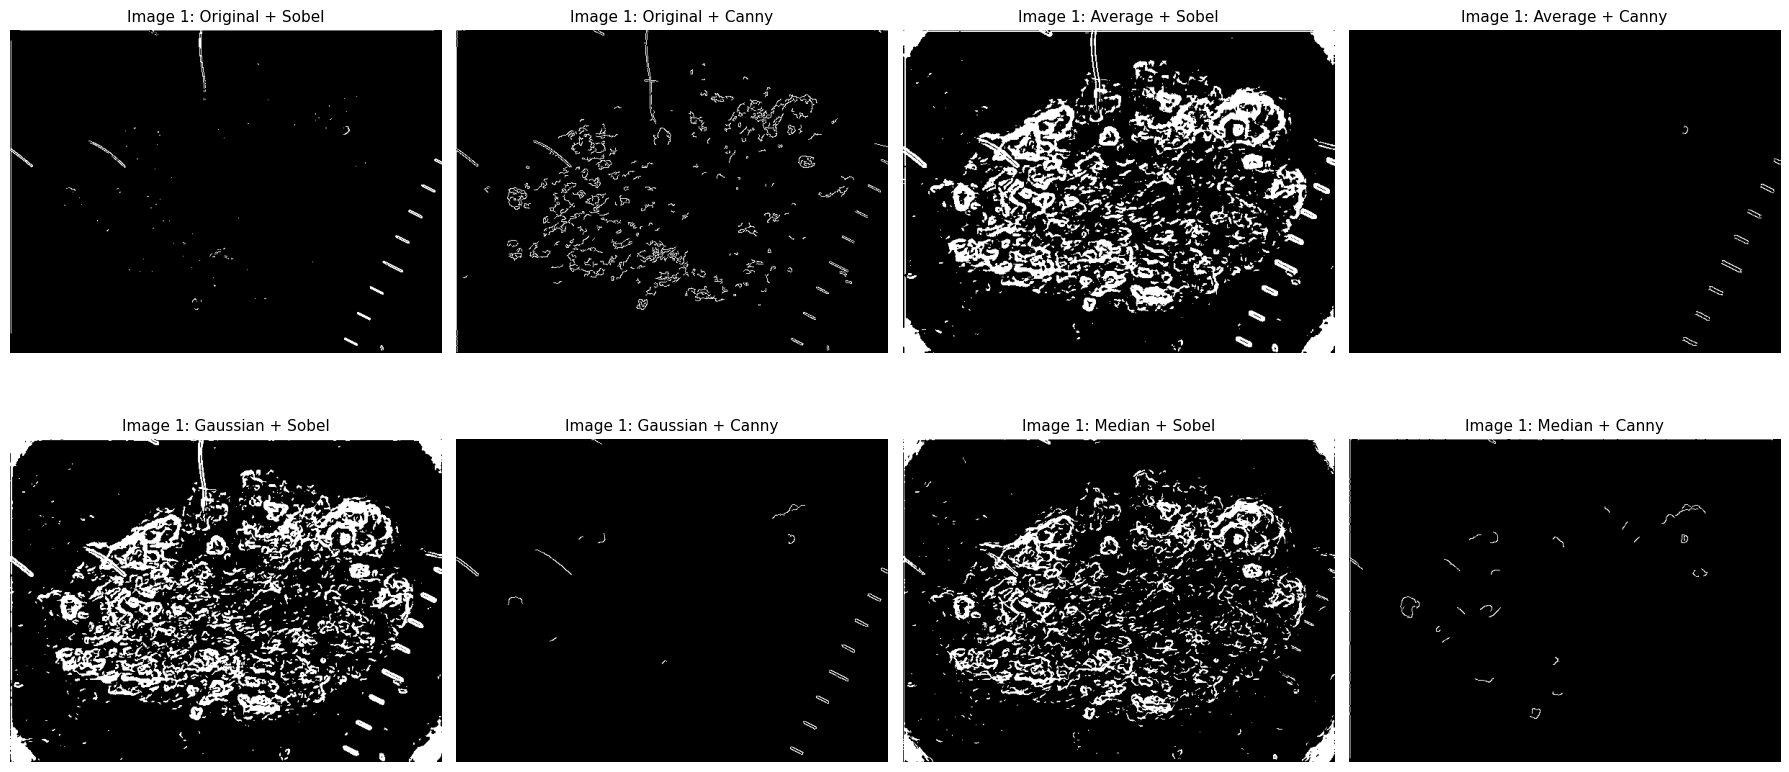

In [14]:
# Visual side-by-side of the 8 methods for Image 1 (edit the name to inspect other images)
show_name = names[0]
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, m in zip(axes.ravel(), order):
    f, o = m.split(" + ")
    ax.imshow(comparison_edges[(show_name, f, o)], cmap="gray"); ax.set_title(f"{show_name}: {m}", fontsize=11); ax.axis("off")
plt.tight_layout(); plt.show()

# **1. Why is Gaussian filtering applied before Canny detection?**

Canny works by measuring how quickly pixel intensity changes, and that kind of measurement makes noise worse. Skin images contain a lot of tiny disturbances like sensor noise, skin texture and hair, and without smoothing each of them would show up as an edge. The Gaussian filter blurs each pixel with its neighbours, giving closer neighbours more weight. This removes the small stuff but keeps the large, real change at the lesion border. The result is fewer false edges and a smoother, more connected outline. I preferred it over the average filter, which blurs everything equally and can smear the border, and over the median filter, which is slower.

# **2. How did the three Canny threshold settings affect the result?**

The three settings gave clearly different edge maps.

50–100: this setting picked up almost everything, including hair, skin texture and the dark corners of the image. The lesion outline was there but hard to separate from all the extra edges.
100–200: this gave a good balance. Most of the clutter disappeared and the lesion outline stayed mostly continuous.
150–250: this setting was so strict that only the strongest edges survived. The image was clean, but weaker parts of the lesion border vanished, which left gaps in the outline.

So a lower threshold gives more detail and more noise, and a higher threshold gives a cleaner image but risks losing the real border.

# **3. Which threshold produced the best lesion boundary?**

The 100–200 setting gave the best boundary for most of my images. It kept the outline mostly closed while rejecting most of the hair and texture edges. At 50–100 the clutter made it harder to pick out the lesion contour, and at 150–250 the gaps made it hard to close the contour at all. This matches the scores in my Task 4 table.

# **4. Why are edges useful for detecting skin lesions?**

A lesion is usually darker or a different colour from the skin around it, so its border is exactly where the intensity changes sharply, and that is what edge detection finds. It needs no training data and gives us the lesion's shape and position directly. Once we have a closed boundary we can measure the area and perimeter, and also look at how irregular the border is. Border irregularity is one of the warning signs doctors look for in melanoma.

# **5. What problems did you observe in detecting the lesion boundary?**

The main problem was hair. Hairs create long, strong edges that run across the lesion or attach to its outline, so the detected boundary sometimes included extra bits. Lesions with soft or faded borders were also difficult, because their edges came out broken and the contour wouldn't close. In some images the dark corners and edges of the frame created false edges that could be mistaken for the lesion. Colour variation inside a lesion also produced internal edges. Finally, a single threshold setting doesn't suit every image, because contrast varies from one image to the next. The pixel values for area and perimeter are only relative, since the dataset gives no real-world scale, and I had no ground-truth masks to compare against.

# **6. How could your method be improved?**

The biggest gain would come from removing hair before edge detection, for example with black-hat filtering followed by inpainting. Choosing the Canny thresholds automatically for each image, based on its own intensity values, would fix the problem of one setting not fitting every image. I could also crop out the dark corners before detection. To handle broken outlines, I could use methods that complete the boundary, such as active contours, watershed or GrabCut. Combining edge detection with colour-based thresholding would also help. Finally, I could measure accuracy against the official HAM10000 segmentation masks using Dice or IoU, and a deep learning model like U-Net would probably do better than any classical method.